In [39]:
from utils import *
import pandas as pd
import glob, os
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [40]:
def nice_solver_name(solver: str):
    if "AdditiveSchwarz" in solver:
        return "Additive"
    if "HybridSchwarz" in solver:
        return "Hybrid"
    return solver

In [41]:
dfs = []
for file in glob.glob("../results/experiment_solvers*d2*f12*.csv"):
    dfs.append(pd.read_csv(file))
    print(file)
df = pd.concat(dfs, ignore_index=True)
df = process_experiments_df(df)

../results/experiment_solvers_d2_p1_f12.csv


In [42]:
metadata_df = df.apply(extract_row_metadata, axis=1)
metadata_cols = metadata_df.columns.tolist()
df = pd.concat([df, metadata_df], axis=1)
df["solve time"] = df["solve times"].apply(safe_map(min))
df["solver"] = df["solver"].apply(nice_solver_name)
summary = df.pivot_table(
    index=["coarse m", "solvers m", "fine m"],
    columns="solver",
    values=metadata_cols,
    aggfunc="min",
)

In [43]:
def get_plot_df(coarse_m: int, solver: str):
    data = (
        summary.xs(coarse_m, level="coarse m")
        .xs(solver, level="solver", axis=1)
        .reset_index()
        .set_index("solvers m")
        .copy()
    )
    total_local_solvers = "local solvers"
    total_coarse_solver = "coarse solver"
    total_preconditioner_rest = "other preconditioner components"
    total_not_preconditioner = "outer PCG"
    data["local solvers time"] = 0
    data["coarse solver time"] = 0
    data["preconditioner time"] = 0
    data[total_local_solvers] = data["local solvers time"] * data["iterations"]
    data[total_coarse_solver] = data["coarse solver time"] * data["iterations"]
    data[total_preconditioner_rest] = (
        data["preconditioner time"]
        - data["local solvers time"]
        - data["coarse solver time"]
    ) * data["iterations"]
    data[total_not_preconditioner] = (
        data["cg time"]
        - data[total_preconditioner_rest]
        - data[total_coarse_solver]
        - data[total_local_solvers]
    )
    to_plot = (
        data[
            [
                total_not_preconditioner,
                total_preconditioner_rest,
                total_coarse_solver,
                total_local_solvers,
            ]
        ]
        / 1000
    )
    to_plot.sort_index(inplace=True, key=lambda x: x.map(mesh_to_key))
    to_plot.rename(index=lambda s: f"${format_mesh(s)}$", inplace=True)
    return to_plot

In [44]:
coarse_meshes = summary.index.get_level_values("coarse m").unique().to_list()
coarse_meshes.sort(key=mesh_to_key)
coarse_meshes

['C10', 'S10', 'C11', 'S11', 'C12', 'S12']

In [45]:
solvers = summary.columns.get_level_values("solver").unique().tolist()
solvers

['Additive', 'Hybrid']

Text(0.04, 0.94, '$\\mathcal{T}_\\mathcal{H}\\rightarrow$')

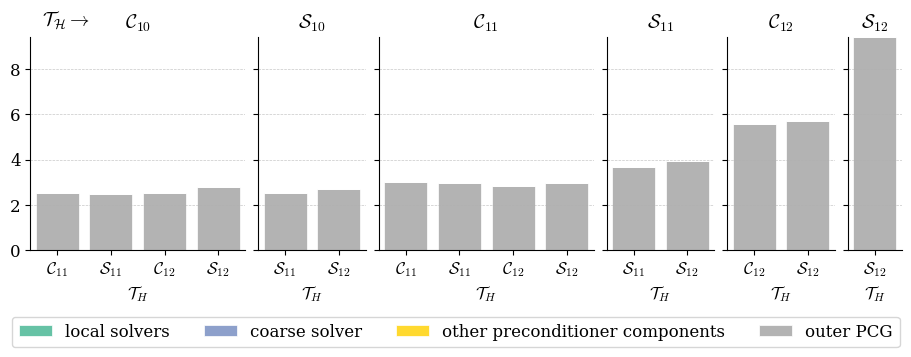

In [48]:
width_ratios = [
    len(summary.xs(cm, level="coarse m").index.get_level_values("solvers m").unique())
    for cm in coarse_meshes
]
fig, axes = plt.subplots(
    1,
    len(coarse_meshes),
    figsize=(9, 3),
    layout="constrained",
    sharey="row",
    width_ratios=width_ratios,
)
linthresh = 1
for ax, coarse_m in zip(axes.flat, coarse_meshes):
    plot_clustered_stacked(
        ax,
        [get_plot_df(coarse_m, solver) for solver in ["Additive"]],
        solvers,
        add_legend=False,
    )
    ax.set_title(f"${format_mesh(coarse_m)}$")
    ax.set_xlabel("$\\mathcal{{T}}_H$")
    if coarse_m == (8, "C"):
        ax.set_ylabel("solution time (s)")

handles, labels = ax.get_legend_handles_labels()
fig.legend(
    handles[::-1],
    labels[::-1],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.0),
    ncols=4,
)
fig.text(0.04, 0.94, "$\\mathcal{T}_\\mathcal{H}\\rightarrow$", fontsize=14)

# fig.savefig("../docs/defence-media/inv_plots.svg", bbox_inches="tight")

## Setup times

In [49]:
local_solvers_setup_times = summary.pivot_table(
    index=["solvers m"], values=["local solvers setup time"]
)
local_solvers_setup_times

KeyError: 'local solvers setup time'

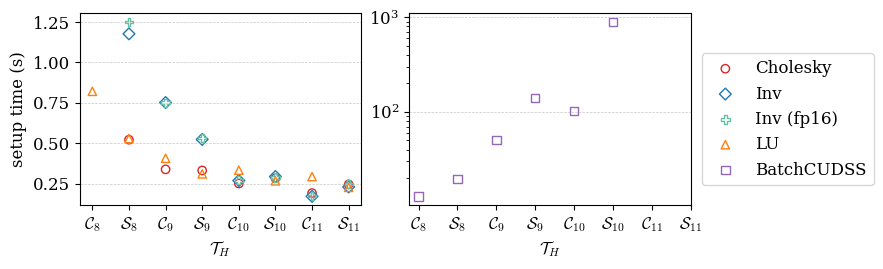

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(7, 2.5), layout="constrained")
for solver in solvers:
    ax = axes[1] if solver == "BatchCUDSS" else axes[0]
    data = local_solvers_setup_times.xs(solver, level="solver", axis=1) / 1000
    ax.scatter(
        range(len(data)),
        data.values,
        label=solver,
        marker=markers[solver],
        color=solver_colors.get(solver, "black"),
        facecolors="none",
    )
for i, ax in enumerate(axes):
    ax.yaxis.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
    ax.set_xticks(range(len(local_solvers_setup_times.index)))
    ax.set_xticklabels(
        [f"${format_mesh(ms)}$" for ms in local_solvers_setup_times.index]
    )
    if i == 0:
        ax.set_ylabel("setup time (s)")
    ax.set_xlabel("$\\mathcal{T}_H$")
    if i == 1:
        ax.set_yscale("log")
fig.legend(loc="right", bbox_to_anchor=(1.25, 0.55), ncols=1)
fig.savefig("../docs/thesis-media/local_solvers_setup_times.svg", bbox_inches="tight")

In [ ]:
coarse_solver_setup_times = summary.pivot_table(
    index=["coarse m"], values=["coarse solver setup time"]
).min(axis=1)
coarse_solver_setup_times

coarse m
(8, C)       802.422119
(8, S)      1239.792236
(9, C)      1080.282959
(9, S)      2081.896667
(10, C)     1922.110107
(10, S)     3871.856934
(11, C)     5551.062988
(11, S)    11073.188477
dtype: float64

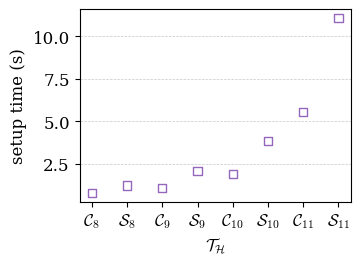

In [ ]:
fig, ax = plt.subplots(figsize=(3.5, 2.5))
ax.scatter(
    range(len(coarse_solver_setup_times)),
    coarse_solver_setup_times.values / 1000,
    marker=markers["BatchCUDSS"],
    edgecolors=solver_colors["BatchCUDSS"],
    facecolors="none",
)
ax.set_xticks(range(len(coarse_solver_setup_times.index)))
ax.set_xticklabels([f"${format_mesh(ms)}$" for ms in coarse_solver_setup_times.index])
ax.yaxis.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
ax.set_ylabel("setup time (s)")
ax.set_xlabel("$\\mathcal{T}_\\mathcal{H}$")
fig.savefig("../docs/thesis-media/coarse_solver_setup_times.svg", bbox_inches="tight")